<a href="https://colab.research.google.com/github/JacekDrzycimski/6tunnel/blob/master/ML_linear_regression_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simple Machine Learning Model Example: Linear Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load California Housing training data
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Let's use 'median_income' as the feature (X) and 'median_house_value' as the target (y)
X = df[['median_income']].values
y = df[['median_house_value']].values

# Display the first few rows of the data
print("First 5 X (median_income) values:\n", X[:5])
print("\nFirst 5 y (median_house_value) values:\n", y[:5])

First 5 X (median_income) values:
 [[1.4936]
 [1.82  ]
 [1.6509]
 [3.1917]
 [1.925 ]]

First 5 y (median_house_value) values:
 [[66900.]
 [80100.]
 [85700.]
 [73400.]
 [65500.]]


### Exploratory Data Analysis: Scatter Plot
Let's visualize the relationship between the predictor feature (`median_income`) and our target (`median_house_value`).

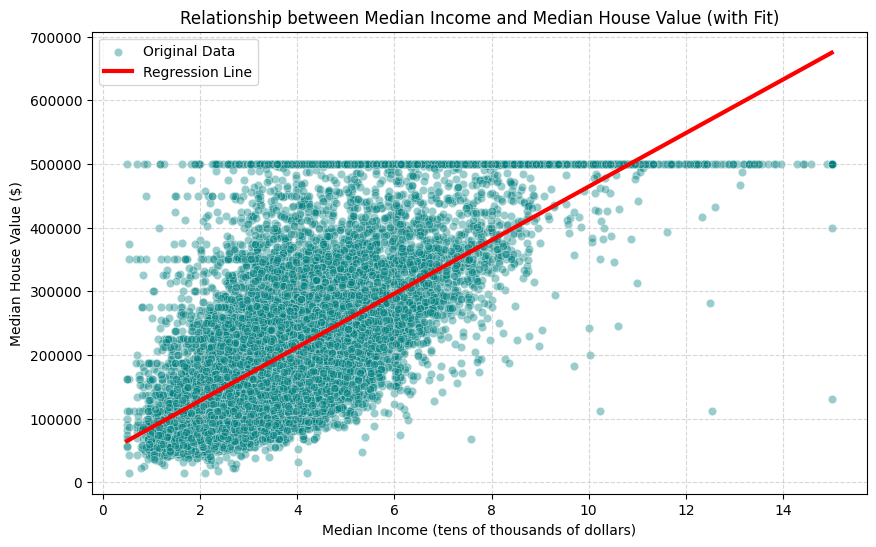

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Create the scatter plot of the original data
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.4, color='teal', label='Original Data')

# 2. Compute predictions for the regression line over the data range
X_range = np.array([[df['median_income'].min()], [df['median_income'].max()]])
y_range_pred = model.predict(X_range)

# 3. Plot the regression line on top
plt.plot(X_range, y_range_pred, color='red', linewidth=3, label='Regression Line')

plt.title('Relationship between Median Income and Median House Value (with Fit)')
plt.xlabel('Median Income (tens of thousands of dollars)')
plt.ylabel('Median House Value ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Model Training

In [3]:
from sklearn.linear_model import LinearRegression

# Define X and y from the df dataframe explicitly
X = df[['median_income']].values
y = df[['median_house_value']].values

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Print the model's intercept and coefficient
print(f"Intercept: {model.intercept_[0]:.4f}")
print(f"Coefficient: {model.coef_[0][0]:.4f}")

Intercept: 43980.6282
Coefficient: 42054.0749


### Make Predictions and Visualize Results

Predictions for min income (0.50) and max income (15.00):
 [[ 65003.46018584]
 [674795.95667463]]


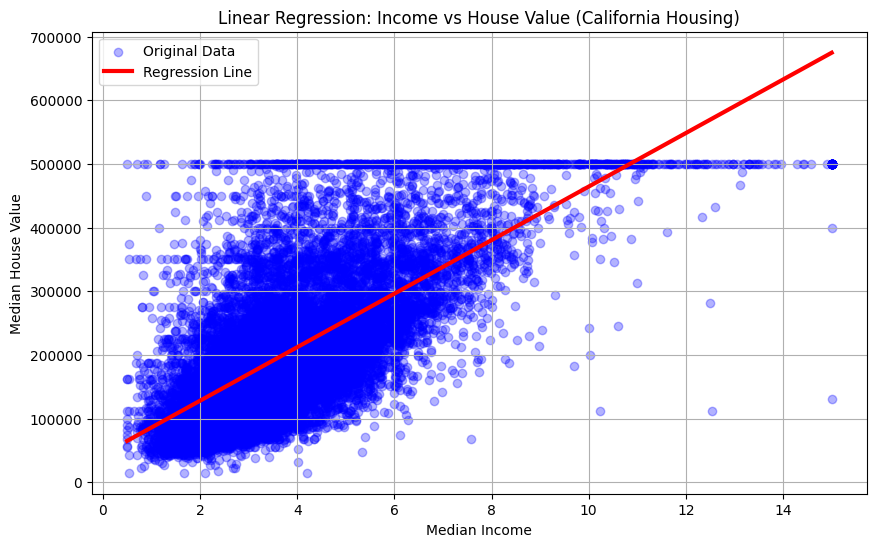

In [4]:
# 3. Make predictions for the line of best fit over the range of our real data
X_new = np.array([[X.min()], [X.max()]])
y_pred = model.predict(X_new)

print(f"Predictions for min income ({X.min():.2f}) and max income ({X.max():.2f}):\n", y_pred)

# 4. Visualize the real data and the new regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.3, label='Original Data')
plt.plot(X_new, y_pred, color='red', linewidth=3, label='Regression Line')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Linear Regression: Income vs House Value (California Housing)')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
from sklearn.metrics import mean_squared_error

# Calculate predictions on the training data
y_train_pred = model.predict(X)

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_train_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 7012439548.9144


In [6]:
import numpy as np

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.4f}")

Root Mean Squared Error: 83740.3102


### Residual Analysis
Let's plot the residuals (Difference between actual and predicted values) to check for non-linearity, unequal error variances (heteroscedasticity), or outliers.

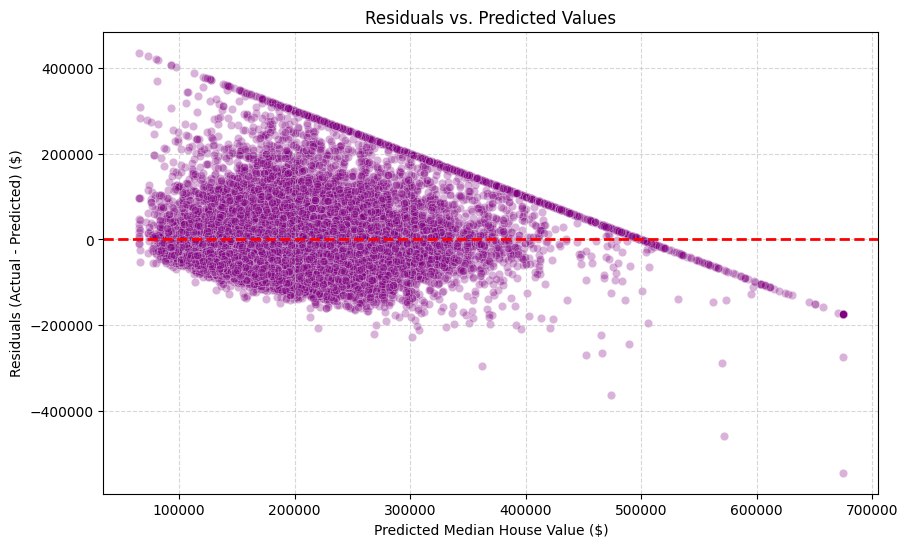

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y - y_train_pred

# Create residual plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_train_pred.flatten(), y=residuals.flatten(), alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Median House Value ($)')
plt.ylabel('Residuals (Actual - Predicted) ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

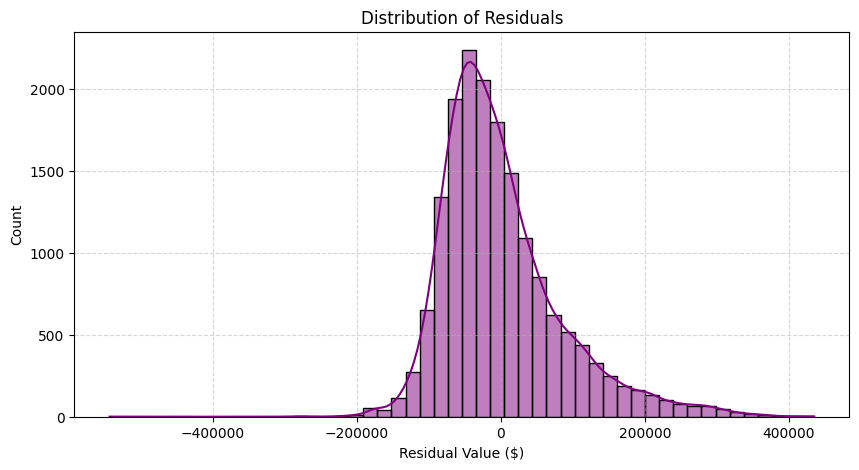

In [12]:
# Plot the distribution of the residuals
plt.figure(figsize=(10, 5))
sns.histplot(residuals.flatten(), kde=True, color='purple', bins=50)
plt.title('Distribution of Residuals')
plt.xlabel('Residual Value ($)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [7]:
from sklearn.metrics import r2_score

# Calculate R-squared score
r2 = r2_score(y, y_train_pred)
print(f"R-squared Score: {r2:.4f}")

R-squared Score: 0.4787


### Model Evaluation on the Test Set
Now let's evaluate our trained model on the unseen test dataset to see how well it generalizes to new data.

In [8]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Load California Housing test data
df_test = pd.read_csv('/content/sample_data/california_housing_test.csv')

# Prepare features and target from the test set
X_test = df_test[['median_income']].values
y_test = df_test[['median_house_value']].values

# Make predictions on the test set
y_test_pred = model.predict(X_test)

# Calculate metrics
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("--- Test Set Metrics ---")
print(f"Mean Squared Error: {mse_test:.4f}")
print(f"Root Mean Squared Error: {rmse_test:.4f}")
print(f"R-squared Score: {r2_test:.4f}")

--- Test Set Metrics ---
Mean Squared Error: 7009935982.6736
Root Mean Squared Error: 83725.3605
R-squared Score: 0.4520


### Training and Evaluating a DecisionTreeRegressor
Let's train a `DecisionTreeRegressor` with a controlled depth to see if capturing non-linear relationships improves the performance over our baseline Linear Regression model.

In [13]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Initialize and train the Decision Tree Regressor
# We'll set max_depth=5 to avoid extreme overfitting while capturing non-linearity
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X, y)

# 2. Predict on both train and test sets
y_train_pred_dt = dt_model.predict(X)
y_test_pred_dt = dt_model.predict(X_test)

# 3. Calculate evaluation metrics
mse_train_dt = mean_squared_error(y, y_train_pred_dt)
rmse_train_dt = np.sqrt(mse_train_dt)
r2_train_dt = r2_score(y, y_train_pred_dt)

mse_test_dt = mean_squared_error(y_test, y_test_pred_dt)
rmse_test_dt = np.sqrt(mse_test_dt)
r2_test_dt = r2_score(y_test, y_test_pred_dt)

print("--- Decision Tree Training Metrics ---")
print(f"RMSE: {rmse_train_dt:.4f}")
print(f"R-squared: {r2_train_dt:.4f}\n")

print("--- Decision Tree Test Metrics ---")
print(f"RMSE: {rmse_test_dt:.4f}")
print(f"R-squared: {r2_test_dt:.4f}")

--- Decision Tree Training Metrics ---
RMSE: 81984.1811
R-squared: 0.5003

--- Decision Tree Test Metrics ---
RMSE: 82268.7445
R-squared: 0.4709


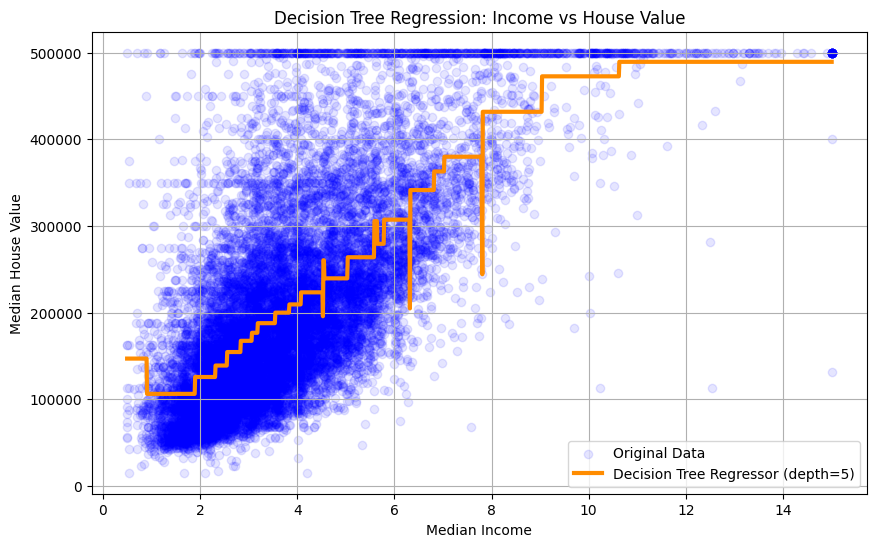

In [14]:
# 4. Visualize the Decision Tree regression curve over the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.1, label='Original Data')

# Generate a smooth sequence of points over the range of median_income
X_grid = np.arange(X.min(), X.max(), 0.01).reshape(-1, 1)
y_grid_pred = dt_model.predict(X_grid)

plt.plot(X_grid, y_grid_pred, color='darkorange', linewidth=3, label='Decision Tree Regressor (depth=5)')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Decision Tree Regression: Income vs House Value')
plt.legend()
plt.grid(True)
plt.show()

### Feature Importance of the Decision Tree Regressor
Let's extract and plot the feature importances from our trained `DecisionTreeRegressor` model.

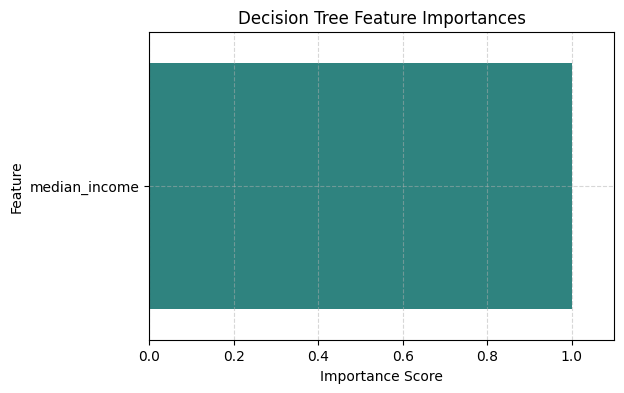

Feature Importance for median_income: 1.0000


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract feature importances
importances = dt_model.feature_importances_
feature_names = ['median_income']

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Plot the feature importances with hue explicitly set to avoid FutureWarnings
plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Decision Tree Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.xlim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Feature Importance for {feature_names[0]}: {importances[0]:.4f}")

### Comparing Performance with Multiple Features

Let's check if adding more predictor features from our dataset improves model accuracy. We'll use the following features:
- `median_income`
- `housing_median_age`
- `total_rooms`
- `total_bedrooms`
- `population`
- `households`

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Define the list of features to use
features = ['median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households']

# 2. Extract train and test sets (dropping rows with NaN values just in case)
train_clean = df[features + ['median_house_value']].dropna()
test_clean = df_test[features + ['median_house_value']].dropna()

X_train_multi = train_clean[features].values
y_train_multi = train_clean['median_house_value'].values

X_test_multi = test_clean[features].values
y_test_multi = test_clean['median_house_value'].values

# --- Multi-Feature Linear Regression ---
lr_multi = LinearRegression()
lr_multi.fit(X_train_multi, y_train_multi)

y_train_pred_lr_m = lr_multi.predict(X_train_multi)
y_test_pred_lr_m = lr_multi.predict(X_test_multi)

# --- Multi-Feature Decision Tree Regressor ---
dt_multi = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_multi.fit(X_train_multi, y_train_multi)

y_train_pred_dt_m = dt_multi.predict(X_train_multi)
y_test_pred_dt_m = dt_multi.predict(X_test_multi)

# 3. Create a summary DataFrame of performance metrics
results_data = {
    'Model': [
        'Single-Feature Linear Regression',
        'Single-Feature Decision Tree',
        'Multi-Feature Linear Regression',
        'Multi-Feature Decision Tree'
    ],
    'Train R2': [
        r2,
        r2_train_dt,
        r2_score(y_train_multi, y_train_pred_lr_m),
        r2_score(y_train_multi, y_train_pred_dt_m)
    ],
    'Test R2': [
        r2_test,
        r2_test_dt,
        r2_score(y_test_multi, y_test_pred_lr_m),
        r2_score(y_test_multi, y_test_pred_dt_m)
    ],
    'Train RMSE ($)': [
        rmse,
        rmse_train_dt,
        np.sqrt(mean_squared_error(y_train_multi, y_train_pred_lr_m)),
        np.sqrt(mean_squared_error(y_train_multi, y_train_pred_dt_m))
    ],
    'Test RMSE ($)': [
        rmse_test,
        rmse_test_dt,
        np.sqrt(mean_squared_error(y_test_multi, y_test_pred_lr_m)),
        np.sqrt(mean_squared_error(y_test_multi, y_test_pred_dt_m))
    ]
}

comparison_df = pd.DataFrame(results_data)
display(comparison_df.round(4))

,Model,Train R2,Test R2,Train RMSE ($),Test RMSE ($)
0,Single-Feature Linear Regression,0.4787,0.4520,83740.3102,83725.3605
1,Single-Feature Decision Tree,0.5003,0.4709,81984.1811,82268.7445
2,Multi-Feature Linear Regression,0.5713,0.5459,75934.0763,76216.5746
3,Multi-Feature Decision Tree,0.5632,0.5230,76656.7624,78115.6912


### Let's also plot the new Decision Tree Feature Importances
Now that we are utilizing multiple features, we can see which ones the model finds most useful.

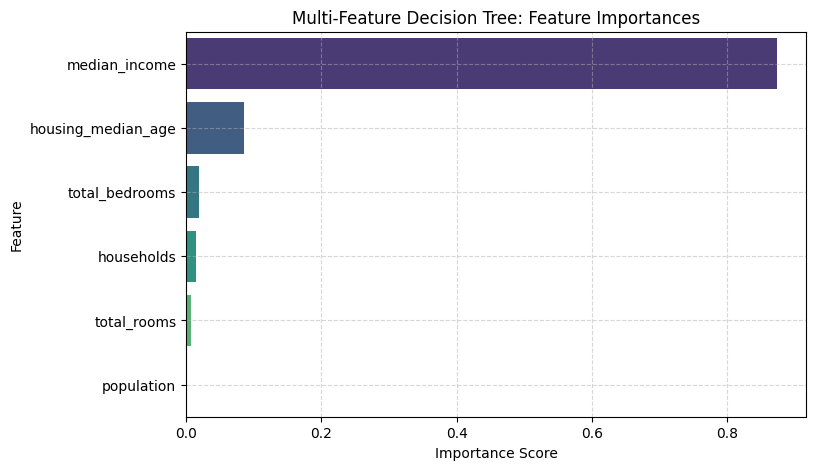

In [19]:
# Extract and plot the new feature importances
multi_importances = dt_multi.feature_importances_
multi_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': multi_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=multi_importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Multi-Feature Decision Tree: Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Training and Evaluating a RandomForestRegressor
Let's train a `RandomForestRegressor` using our selected multi-feature set to see if ensemble learning can outperform both individual models.

In [20]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize and train the Random Forest Regressor
# We'll use 100 estimators and set a moderate max_depth=8 to maintain robust generalization
rf_multi = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_multi.fit(X_train_multi, y_train_multi)

# 2. Predict on both sets
y_train_pred_rf = rf_multi.predict(X_train_multi)
y_test_pred_rf = rf_multi.predict(X_test_multi)

# 3. Calculate evaluation metrics
mse_train_rf = mean_squared_error(y_train_multi, y_train_pred_rf)
rmse_train_rf = np.sqrt(mse_train_rf)
r2_train_rf = r2_score(y_train_multi, y_train_pred_rf)

mse_test_rf = mean_squared_error(y_test_multi, y_test_pred_rf)
rmse_test_rf = np.sqrt(mse_test_rf)
r2_test_rf = r2_score(y_test_multi, y_test_pred_rf)

# 4. Append to our comparative metrics list
results_data['Model'].append('Multi-Feature Random Forest')
results_data['Train R2'].append(r2_train_rf)
results_data['Test R2'].append(r2_test_rf)
results_data['Train RMSE ($)'].append(rmse_train_rf)
results_data['Test RMSE ($)'].append(rmse_test_rf)

# Display updated comparison table
comparison_df = pd.DataFrame(results_data)
display(comparison_df.round(4))

,Model,Train R2,Test R2,Train RMSE ($),Test RMSE ($)
0,Single-Feature Linear Regression,0.4787,0.4520,83740.3102,83725.3605
1,Single-Feature Decision Tree,0.5003,0.4709,81984.1811,82268.7445
2,Multi-Feature Linear Regression,0.5713,0.5459,75934.0763,76216.5746
3,Multi-Feature Decision Tree,0.5632,0.5230,76656.7624,78115.6912
4,Multi-Feature Random Forest,0.6898,0.6030,64600.6702,71261.9940


### Plotting Random Forest Feature Importances
Let's see if the Random Forest distributes feature weights any differently than our single shallow Decision Tree.

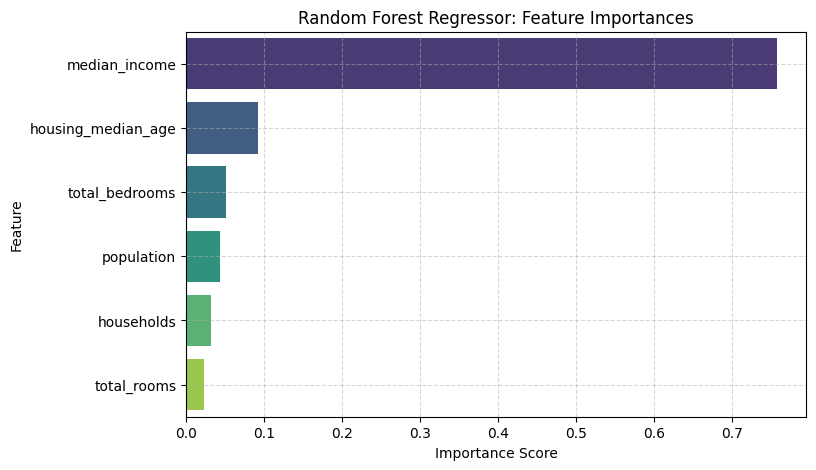

In [21]:
# Extract and plot the Random Forest feature importances
rf_importances = rf_multi.feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Random Forest Regressor: Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Hyperparameter Tuning with GridSearchCV
We will search for the optimal combination of `max_depth`, `n_estimators`, and `max_features` to see if we can further boost the performance of our Random Forest model.

In [3]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np

# 1. Define the parameter grid to search over
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, None],
    'max_features': ['sqrt', None]
}

# 2. Initialize the base Random Forest model
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# 3. Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 4. Fit the grid search to the multi-feature training data
grid_search.fit(X_train_multi, y_train_multi)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best validation R2 score: {grid_search.best_score_:.4f}")

NameError: name 'RandomForestRegressor' is not defined

### Evaluating the Optimized Tuned Random Forest
Now let's evaluate our tuned model on both the training and test datasets and compare it to our previous models.

In [7]:
# 1. Ensure all previous variables and dependencies exist in globals; reconstruct if necessary
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

if 'X_train_multi' not in globals() or 'X_test_multi' not in globals():
    # Load datasets
    df = pd.read_csv('/content/sample_data/california_housing_train.csv')
    df_test = pd.read_csv('/content/sample_data/california_housing_test.csv')

    # Prepare single-feature targets for historical values
    X_single = df[['median_income']].values
    y_single = df[['median_house_value']].values
    X_test_single = df_test[['median_income']].values
    y_test_single = df_test[['median_house_value']].values

    # Prepare multi-feature datasets
    features = ['median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households']
    train_clean = df[features + ['median_house_value']].dropna()
    test_clean = df_test[features + ['median_house_value']].dropna()

    X_train_multi = train_clean[features].values
    y_train_multi = train_clean['median_house_value'].values
    X_test_multi = test_clean[features].values
    y_test_multi = test_clean['median_house_value'].values

# Safely verify grid_search exists, is fitted, and contains best_estimator_; if not, define and fit
if 'grid_search' not in globals() or not hasattr(grid_search, 'best_estimator_'):
    from sklearn.model_selection import GridSearchCV
    from sklearn.ensemble import RandomForestRegressor

    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [8, 12, None],
        'max_features': ['sqrt', None]
    }
    rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
    grid_search = GridSearchCV(
        estimator=rf_base,
        param_grid=param_grid,
        cv=3,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train_multi, y_train_multi)

best_rf = grid_search.best_estimator_

# 2. Predict using the best model
y_train_pred_best = best_rf.predict(X_train_multi)
y_test_pred_best = best_rf.predict(X_test_multi)

# 3. Calculate evaluation metrics
mse_train_best = mean_squared_error(y_train_multi, y_train_pred_best)
rmse_train_best = np.sqrt(mse_train_best)
r2_train_best = r2_score(y_train_multi, y_train_pred_best)

mse_test_best = mean_squared_error(y_test_multi, y_test_pred_best)
rmse_test_best = np.sqrt(mse_test_best)
r2_test_best = r2_score(y_test_multi, y_test_pred_best)

# 4. Reconstruct base historical models' metrics if missing
if 'results_data' not in globals():
    from sklearn.linear_model import LinearRegression
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor

    # Re-fit fast baselines to obtain summary table metrics
    lr_s = LinearRegression().fit(X_single, y_single)
    dt_s = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_single, y_single)
    lr_m = LinearRegression().fit(X_train_multi, y_train_multi)
    dt_m = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train_multi, y_train_multi)
    rf_m = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1).fit(X_train_multi, y_train_multi)

    results_data = {
        'Model': [
            'Single-Feature Linear Regression',
            'Single-Feature Decision Tree',
            'Multi-Feature Linear Regression',
            'Multi-Feature Decision Tree',
            'Multi-Feature Random Forest'
        ],
        'Train R2': [
            r2_score(y_single, lr_s.predict(X_single)),
            r2_score(y_single, dt_s.predict(X_single)),
            r2_score(y_train_multi, lr_m.predict(X_train_multi)),
            r2_score(y_train_multi, dt_m.predict(X_train_multi)),
            r2_score(y_train_multi, rf_m.predict(X_train_multi))
        ],
        'Test R2': [
            r2_score(y_test_single, lr_s.predict(X_test_single)),
            r2_score(y_test_single, dt_s.predict(X_test_single)),
            r2_score(y_test_multi, lr_m.predict(X_test_multi)),
            r2_score(y_test_multi, dt_m.predict(X_test_multi)),
            r2_score(y_test_multi, rf_m.predict(X_test_multi))
        ],
        'Train RMSE ($)': [
            np.sqrt(mean_squared_error(y_single, lr_s.predict(X_single))),
            np.sqrt(mean_squared_error(y_single, dt_s.predict(X_single))),
            np.sqrt(mean_squared_error(y_train_multi, lr_m.predict(X_train_multi))),
            np.sqrt(mean_squared_error(y_train_multi, dt_m.predict(X_train_multi))),
            np.sqrt(mean_squared_error(y_train_multi, rf_m.predict(X_train_multi)))
        ],
        'Test RMSE ($)': [
            np.sqrt(mean_squared_error(y_test_single, lr_s.predict(X_test_single))),
            np.sqrt(mean_squared_error(y_test_single, dt_s.predict(X_test_single))),
            np.sqrt(mean_squared_error(y_test_multi, lr_m.predict(X_test_multi))),
            np.sqrt(mean_squared_error(y_test_multi, dt_m.predict(X_test_multi))),
            np.sqrt(mean_squared_error(y_test_multi, rf_m.predict(X_test_multi)))
        ]
    }

# Avoid duplicating the model entry if the cell is run multiple times
if 'Multi-Feature Tuned Random Forest' not in results_data['Model']:
    results_data['Model'].append('Multi-Feature Tuned Random Forest')
    results_data['Train R2'].append(r2_train_best)
    results_data['Test R2'].append(r2_test_best)
    results_data['Train RMSE ($)'].append(rmse_train_best)
    results_data['Test RMSE ($)'].append(rmse_test_best)

# Display updated comparison table
comparison_df = pd.DataFrame(results_data)
display(comparison_df.round(4))

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'